# Glass-Box PPO on an LLM — from scratch, every tensor visible

**Session 2 lab · companion to the PPO lecture.** No `PPOTrainer`. We build the loop by hand so each term from the slides is a printed tensor you can inspect and a dial you can turn.

### The cast (RLHF's four models, here three + a function)
| Role | In this lab |
|---|---|
| **Actor** (policy $\pi_\theta$) | GPT-2 + a value head — the thing we train |
| **Critic** (value $V_\phi$) | a linear value head on GPT-2's last hidden state |
| **Reference** $\pi_\text{ref}$ | a frozen copy of GPT-2 — the KL leash anchor |
| **Reward model** | a *trivial verifiable function* (count positive words) — no model to train |

Using a trivial reward keeps the spotlight on the **mechanics**: rollout → per-token reward shaping (terminal reward $-$ KL penalty) → GAE → importance ratio → clip → update.

### The three dials (everything from the lecture, made turnable)
- **clip $\epsilon$** — the trust region width in PPO-Clip → watch `clipfrac` and stability
- **GAE $\lambda$** — the bias/variance knob on advantages
- **KL coefficient $\beta$** — the leash to the reference. The headline experiment: sweep $\beta$ to watch **reward hacking / KL blow-up** (Goodhart, live).

> Runs on a single GPU in a few minutes with `gpt2` (124M). CPU works for tiny `batch_size`/`iters`. Swap the model name for a 0.5–1.5B model if you want — the loop is unchanged.

In [1]:
# If needed:  pip install torch transformers matplotlib
import copy, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, replace
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0)
print("device:", device)

/home/labs/antebilab/guyilan/Courses/Nebius/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1 · The dials (config)

Edit this cell and re-run the training cell to feel each knob. The defaults are *starting points* — with a from-scratch loop on a trivial reward you may need to nudge `lr` / `iters` to see clean movement.

**Important, and itself a teaching point:** $\beta$ is only meaningful *relative to the reward scale*. Our reward is "number of positive words" (roughly 0–5), so a useful $\beta$ lives around 0.02–0.3. With a differently-scaled reward you'd rescale $\beta$ — exactly the scale-dependence you saw with DPO's $\beta$ as an implicit KL weight.

In [2]:
@dataclass
class PPOConfig:
    model_name: str = "gpt2"      # try "Qwen/Qwen2.5-0.5B" for a bigger actor
    prompt: str = "I watched the movie last night and"
    # --- the three dials ---
    clip_eps: float = 0.2         # PPO-Clip trust region width
    gae_lambda: float = 0.95      # GAE bias/variance knob
    kl_coef: float = 0.05         # beta: KL leash to reference  <-- the reward-hacking dial
    # --- rollout / optimization ---
    gamma: float = 1.0
    batch_size: int = 16          # completions sampled per iteration
    gen_len: int = 16             # response tokens per completion
    ppo_epochs: int = 4           # reuse each rollout this many times (off-policy-ish)
    lr: float = 2e-5
    iters: int = 60
    vf_coef: float = 0.1
    ent_coef: float = 0.0
    normalize_adv: bool = True
    temperature: float = 1.0

cfg = PPOConfig()
cfg

PPOConfig(model_name='gpt2', prompt='I watched the movie last night and', clip_eps=0.2, gae_lambda=0.95, kl_coef=0.05, gamma=1.0, batch_size=16, gen_len=16, ppo_epochs=4, lr=2e-05, iters=60, vf_coef=0.1, ent_coef=0.0, normalize_adv=True, temperature=1.0)

## 2 · Actor+critic and the frozen reference

The policy is GPT-2 with a scalar **value head** bolted onto the last hidden state, so one forward pass gives us both `logits` (actor) and `values` (critic). The reference is a frozen, grad-free copy — it never moves, and KL is measured against it.

In [3]:
class PolicyWithValueHead(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.backbone = AutoModelForCausalLM.from_pretrained(model_name)
        h = self.backbone.config.hidden_size
        self.v_head = nn.Linear(h, 1)
        nn.init.normal_(self.v_head.weight, std=1e-3); nn.init.zeros_(self.v_head.bias)
    def forward(self, ids, attn=None):
        out = self.backbone(input_ids=ids, attention_mask=attn, output_hidden_states=True)
        values = self.v_head(out.hidden_states[-1]).squeeze(-1)   # (B, S)
        return out.logits, values                                # (B,S,V), (B,S)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.pad_token = tokenizer.eos_token

policy = PolicyWithValueHead(cfg.model_name).to(device)
ref = AutoModelForCausalLM.from_pretrained(cfg.model_name).to(device).eval()
for p in ref.parameters(): p.requires_grad_(False)
print("loaded", cfg.model_name, "| params:", sum(p.numel() for p in policy.parameters())/1e6, "M")

loaded gpt2 | params: 124.440577 M


## 3 · The trivial, verifiable reward

A scalar per completion. Swap it freely — that's the only "reward model" here. Default rewards positivity (continuity with the sentiment PPO demo you'll show next). Over-optimizing it produces visible word-salad — which is the point.

In [4]:
POSITIVE = {"good","great","love","loved","amazing","wonderful","best","fantastic",
            "awesome","beautiful","brilliant","perfect","excellent","happy","enjoyed","delightful"}

def reward_fn(texts):
    # Trivial verifiable reward: count of positive words in the response text
    out = []
    for t in texts:
        words = t.lower().replace(".", " ").replace(",", " ").split()
        out.append(float(sum(w in POSITIVE for w in words)))
    return torch.tensor(out, device=device)

# Alternatives to try (uncomment one):
# def reward_fn(texts): return torch.tensor([float(t.count("!")) for t in texts], device=device)
# def reward_fn(texts): return torch.tensor([float(sum(c.isdigit() for c in t)) for t in texts], device=device)

## 4 · The alignment helpers (where everyone gets an off-by-one)

For a sequence `[prompt(0..L-1) | response(L..L+T-1)]`:
- the logits that **predict** response token at absolute position `L+t` sit at position `L+t-1`;
- the value of the **state** from which we emit that token is the hidden value at position `L+t-1`.

So both the response log-probs and the response values come from the slice `[L-1 : L-1+T]`. Getting this slice right is 90% of a correct from-scratch PPO.

In [5]:
def logps_of(logits, ids):
    # log-prob assigned to the realized next tokens (logits already aligned to predict ids)
    return torch.gather(F.log_softmax(logits, -1), 2, ids.unsqueeze(-1)).squeeze(-1)

def entropy_of(logits):
    p = F.softmax(logits, -1); lp = F.log_softmax(logits, -1)
    return -(p * lp).sum(-1)

def aligned_logps_values(model, seq, L, T, is_policy):
    # is_policy=True -> model returns (logits, values); else a plain LM returning .logits
    if is_policy:
        logits, values = model(seq)
    else:
        logits, values = model(seq).logits, None
    pred = logits[:, L-1:L-1+T, :]          # predicts the T response tokens
    resp = seq[:, L:L+T]
    lp = logps_of(pred, resp)               # (B,T)
    ent = entropy_of(pred)                  # (B,T)
    V = values[:, L-1:L-1+T] if is_policy else None
    return lp, V, ent

## 5 · Rollout — manual sampling (the glass box)

We sample `B` continuations from the **same** prompt (so all sequences share length → zero padding, and the baseline $V(s_0)$ is comparable across the batch). We sample by hand rather than `.generate()` so the rollout is fully visible.

In [6]:
@torch.no_grad()
def rollout(cfg):
    L = len(tokenizer(cfg.prompt)["input_ids"])
    prompt_ids = torch.tensor(tokenizer(cfg.prompt)["input_ids"], device=device)
    seq = prompt_ids[None].repeat(cfg.batch_size, 1)
    for _ in range(cfg.gen_len):
        logits, _ = policy(seq)
        probs = F.softmax(logits[:, -1] / cfg.temperature, -1)
        nxt = torch.multinomial(probs, 1)
        seq = torch.cat([seq, nxt], 1)
    texts = tokenizer.batch_decode(seq[:, L:], skip_special_tokens=True)
    return seq, L, cfg.gen_len, texts

## 6 · Reward shaping + GAE

Per-token reward is the **KL penalty** at every step plus the **terminal reward** on the last token:
$$r_t = -\beta\,\big(\log\pi_\theta(a_t)-\log\pi_\text{ref}(a_t)\big),\qquad r_{T-1}\mathrel{+}= R(\text{seq}).$$
Then GAE turns per-token rewards + critic values into advantages:
$$\delta_t = r_t + \gamma V_{t+1} - V_t,\qquad A_t = \delta_t + \gamma\lambda A_{t+1},\qquad \text{return}_t = A_t + V_t.$$

In [7]:
def build_rewards(R, kl_tok, beta):
    rew = -beta * kl_tok                       # (B,T) per-token KL penalty
    rew[:, -1] = rew[:, -1] + R                # terminal scalar reward
    return rew

def compute_gae(rewards, values, gamma, lam):
    B, T = rewards.shape
    adv = torch.zeros_like(rewards); last = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        next_v = values[:, t+1] if t+1 < T else torch.zeros(B, device=rewards.device)
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        last = delta + gamma * lam * last
        adv[:, t] = last
    return adv, adv + values

## 7 · 🔍 The single-step glass box — *the centerpiece of this lab*

One rollout, then we print, for the first completion, every quantity from the lecture next to the **decoded token**: old log-prob, reference log-prob, KL, critic value, advantage, return. Then we take **one** update step and print the **importance ratio** and the **clipped vs unclipped surrogate** side by side.

In [8]:
seq, L, T, texts = rollout(cfg)
with torch.no_grad():
    old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
    ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
kl_tok = old_lp - ref_lp
R = reward_fn(texts)
rew = build_rewards(R, kl_tok, cfg.kl_coef)
adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

print("PROMPT:", repr(cfg.prompt))
print("SAMPLE COMPLETION [0]:", repr(texts[0]), "| reward R =", R[0].item(), "\n")
resp_tokens = seq[0, L:L+T]
hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
print(hdr); print("-"*len(hdr))
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(resp_tokens[t]))
    print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
          f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

PROMPT: 'I watched the movie last night and'
SAMPLE COMPLETION [0]: ' thought this is what kind of results the man has been getting.\n\n"' | reward R = 0.0 

       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
  ' thought'   -3.148   -3.148   0.000   0.296  -0.142   0.154
     ' this'   -3.598   -3.598   0.000   0.233  -0.083   0.150
       ' is'   -1.668   -1.668   0.000   0.198  -0.050   0.148
     ' what'   -2.898   -2.898   0.000   0.237  -0.094   0.143
     ' kind'   -5.899   -5.899   0.000   0.241  -0.103   0.138
       ' of'   -0.002   -0.002   0.000   0.569  -0.454   0.115
  ' results'   -7.815   -7.815   0.000   0.255  -0.147   0.108
      ' the'   -2.908   -2.908   0.000   0.282  -0.184   0.099


In [9]:
# --- one update step, printing the ratio and the clipped surrogate ---
adv_n = (adv - adv.mean()) / (adv.std() + 1e-8) if cfg.normalize_adv else adv
new_lp, new_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)  # == old on step 1
ratio = torch.exp(new_lp - old_lp)
unclipped = ratio * adv_n
clipped = torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps) * adv_n
surrogate = torch.min(unclipped, clipped)

print("On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):")
print(f"{'token':>12}{'ratio':>9}{'adv_norm':>10}{'unclip':>9}{'clip':>9}{'used':>9}")
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(seq[0, L+t]))
    print(f"{tok:>12}{ratio[0,t]:>9.3f}{adv_n[0,t]:>10.3f}{unclipped[0,t]:>9.3f}"
          f"{clipped[0,t]:>9.3f}{surrogate[0,t]:>9.3f}")
print("\nAfter several PPO epochs the ratio drifts from 1 and the clip starts biting —")
print("that's what `clipfrac` in the training curves measures.")

On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):
       token    ratio  adv_norm   unclip     clip     used
  ' thought'    1.000     0.511    0.511    0.511    0.511
     ' this'    1.000     1.163    1.163    1.163    1.163
       ' is'    1.000     1.518    1.518    1.518    1.518
     ' what'    1.000     1.040    1.040    1.040    1.040
     ' kind'    1.000     0.937    0.937    0.937    0.937
       ' of'    1.000    -2.929   -2.929   -2.929   -2.929
  ' results'    1.000     0.449    0.449    0.449    0.449
      ' the'    1.000     0.049    0.049    0.049    0.049

After several PPO epochs the ratio drifts from 1 and the clip starts biting —
that's what `clipfrac` in the training curves measures.


## 8 · The PPO update and the training loop

For each rollout we run `ppo_epochs` passes (data reuse — the mild off-policy-ness you discussed): recompute new log-probs/values, form the ratio against the **fixed** old log-probs, clip, add a value-function loss and optional entropy bonus, step.

In [10]:
def ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt):
    adv_n = (adv - adv.mean())/(adv.std()+1e-8) if cfg.normalize_adv else adv
    stats = {"clipfrac": [], "pg": [], "vf": [], "ent": []}
    for _ in range(cfg.ppo_epochs):
        new_lp, new_V, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        pg = -torch.min(ratio*adv_n,
                        torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps)*adv_n).mean()
        vf = 0.5 * (new_V - ret).pow(2).mean()
        loss = pg + cfg.vf_coef*vf - cfg.ent_coef*ent.mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        stats["clipfrac"].append(((ratio-1).abs() > cfg.clip_eps).float().mean().item())
        stats["pg"].append(pg.item()); stats["vf"].append(vf.item()); stats["ent"].append(ent.mean().item())
    return {k: sum(v)/len(v) for k,v in stats.items()}

def train(cfg, log_every=10):
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    H = {"reward": [], "kl": [], "clipfrac": [], "entropy": []}
    for it in range(cfg.iters):
        seq, L, T, texts = rollout(cfg)
        with torch.no_grad():
            old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
            ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
        kl_tok = old_lp - ref_lp
        R = reward_fn(texts)
        rew = build_rewards(R, kl_tok, cfg.kl_coef)
        adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)
        s = ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt)
        H["reward"].append(R.mean().item()); H["kl"].append(kl_tok.sum(-1).mean().item())
        H["clipfrac"].append(s["clipfrac"]); H["entropy"].append(s["ent"])
        if it % log_every == 0:
            print(f"it{it:3d}  reward {R.mean():6.3f}  KL/seq {kl_tok.sum(-1).mean():7.3f}"
                  f"  clipfrac {s['clipfrac']:.3f}  ent {s['ent']:.3f}")
    return H

## 9 · Train (with the KL leash on)

Reward should climb while KL stays bounded. If reward is flat, raise `lr` or `iters`; if KL explodes, raise `kl_coef`.

In [11]:
policy_fresh_state = copy.deepcopy(policy.state_dict())  # save for before/after + sweeps
H = train(cfg)

it  0  reward  0.312  KL/seq   0.000  clipfrac 0.370  ent 3.494
it 10  reward  1.062  KL/seq   5.569  clipfrac 0.065  ent 2.740
it 20  reward  4.125  KL/seq  19.343  clipfrac 0.048  ent 1.099
it 30  reward  8.375  KL/seq  35.668  clipfrac 0.082  ent 0.774
it 40  reward 15.750  KL/seq  22.415  clipfrac 0.004  ent 0.101
it 50  reward 14.812  KL/seq  23.776  clipfrac 0.034  ent 0.152


## 10 · The training curves

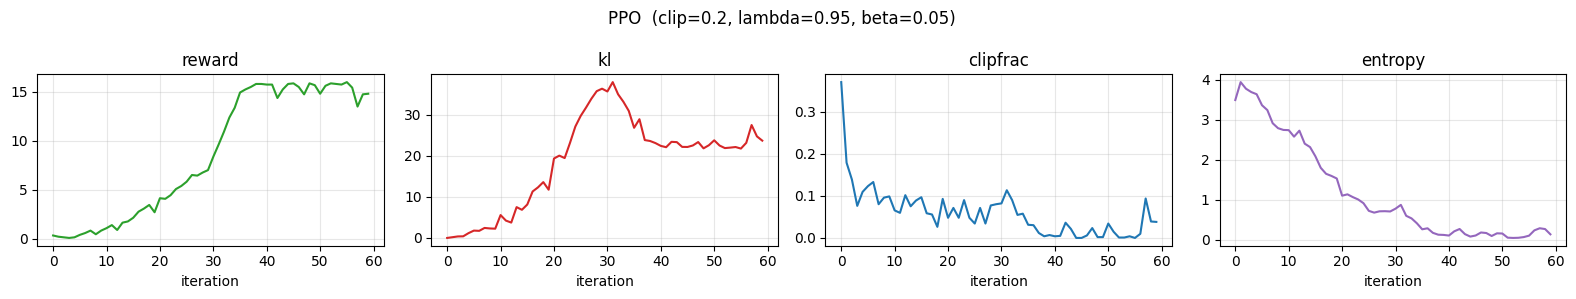

In [12]:
def plot_hist(H, title=""):
    fig, ax = plt.subplots(1, 4, figsize=(16, 3))
    for a,(k,c) in zip(ax, [("reward","tab:green"),("kl","tab:red"),
                            ("clipfrac","tab:blue"),("entropy","tab:purple")]):
        a.plot(H[k], color=c); a.set_title(k); a.set_xlabel("iteration"); a.grid(alpha=.3)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_hist(H, f"PPO  (clip={cfg.clip_eps}, lambda={cfg.gae_lambda}, beta={cfg.kl_coef})")

## 11 · Before vs after — did behavior actually change?

In [13]:
@torch.no_grad()
def sample_some(n=4):
    saved = copy.deepcopy(policy.state_dict()); out = {}
    for label, state in [("BEFORE", policy_fresh_state), ("AFTER", saved)]:
        policy.load_state_dict(state)
        c = replace(cfg, batch_size=n)
        _, _, _, texts = rollout(c)
        out[label] = (texts, reward_fn(texts))
    policy.load_state_dict(saved)
    return out

for label,(texts,R) in sample_some().items():
    print(f"\n=== {label}  (mean reward {R.mean():.2f}) ===")
    for t,r in zip(texts, R): print(f"  [{r:.0f}] {cfg.prompt}{t}")


=== BEFORE  (mean reward 0.00) ===
  [0] I watched the movie last night and I was like, what was that? Hell, I'd barely found out about
  [0] I watched the movie last night and saw these guys, Thompson created these devices, and he created these apps that were
  [0] I watched the movie last night and that wasn't like my childhood. When I see someone carry a gun right there
  [0] I watched the movie last night and thought it was quite emotionally engaging and quite horrifying," Martin told the American Broadcasting Corporation

=== AFTER  (mean reward 16.00) ===
  [16] I watched the movie last night and love love love love love love love love love love love love love love love love
  [16] I watched the movie last night and love love love love love love love love love love love love love love love love
  [16] I watched the movie last night and love love love love love love love love love love love love love love love love
  [16] I watched the movie last night and love love love love lov

## 12 · 🎯 Headline experiment: sweep $\beta$ → reward hacking / KL blow-up

Re-run training from the same fresh weights for several KL coefficients and overlay the curves. The story you'll see:

- **$\beta = 0$** (no leash): reward keeps climbing, **KL runs away**, completions degenerate into positive-word salad — *Goodhart's law*, the model games the reward.
- **moderate $\beta$**: reward improves while KL stays bounded — the regime you actually want.
- **large $\beta$**: the leash dominates, the policy barely moves, reward stays flat.

This is *why* RLHF keeps a reference model and a KL penalty — exactly the term in our PPO loss slide.


--- beta = 0.0 ---
it  0  reward  0.250  KL/seq   0.000  clipfrac 0.389  ent 3.797

--- beta = 0.05 ---
it  0  reward  0.312  KL/seq   0.000  clipfrac 0.400  ent 3.676

--- beta = 0.2 ---
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.388  ent 3.654

--- beta = 1.0 ---
it  0  reward  0.312  KL/seq   0.000  clipfrac 0.394  ent 3.659


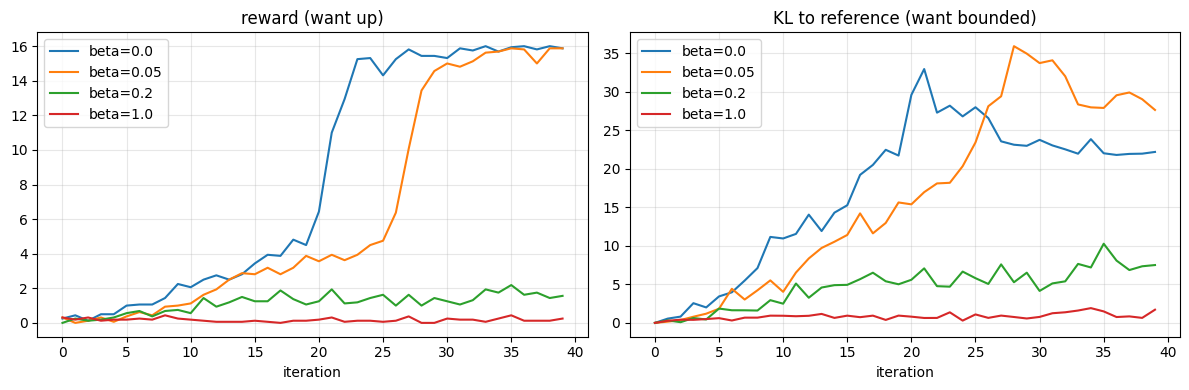

In [14]:
def run_sweep(betas, iters=40):
    runs = {}
    policy_states = {}
    for b in betas:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, kl_coef=b, iters=iters)
        print(f"\n--- beta = {b} ---")
        runs[b] = train(c, log_every=iters)  # only final line
        policy_states[b] = copy.deepcopy(policy.state_dict())
    return runs, policy_states

sweep, sweep_states = run_sweep([0.0, 0.05, 0.2, 1.0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b, H in sweep.items():
    ax[0].plot(H["reward"], label=f"beta={b}")
    ax[1].plot(H["kl"], label=f"beta={b}")
ax[0].set_title("reward (want up)"); ax[1].set_title("KL to reference (want bounded)")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [15]:
# Per-token prediction breakdown for each beta after the sweep (mirrors cell 16)
saved_policy = copy.deepcopy(policy.state_dict())

for b, state in sweep_states.items():
    policy.load_state_dict(state)
    seq, L, T, texts = rollout(replace(cfg, batch_size=1))
    with torch.no_grad():
        old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
    kl_tok = old_lp - ref_lp
    R = reward_fn(texts)
    rew = build_rewards(R, kl_tok, b)
    adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

    print(f"\n=== beta = {b}  |  reward R = {R[0].item():.2f} ===")
    print("SAMPLE COMPLETION:", repr(cfg.prompt + texts[0]))
    resp_tokens = seq[0, L:L+T]
    hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
    print(hdr); print("-" * len(hdr))
    for t in range(min(T, 8)):
        tok = repr(tokenizer.decode(resp_tokens[t]))
        print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
              f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

policy.load_state_dict(saved_policy)


=== beta = 0.0  |  reward R = 16.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and love love love love love love love love love love love love love love love love'
       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
     ' love'   -0.014   -8.482   8.468   5.114   5.270  10.384
     ' love'   -0.008   -7.579   7.572   5.399   5.247  10.646
     ' love'   -0.006   -0.425   0.419   5.432   5.489  10.921
     ' love'   -0.004   -0.686   0.682   5.493   5.714  11.206
     ' love'   -0.008   -0.801   0.793   5.528   5.977  11.505
     ' love'   -0.013   -0.748   0.735   5.551   6.268  11.818
     ' love'   -0.016   -0.628   0.613   5.564   6.583  12.148
     ' love'   -0.016   -0.511   0.495   5.573   6.920  12.494

=== beta = 0.05  |  reward R = 16.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and great great great great great great great great great great great great great great great great'

<All keys matched successfully>

## 13 · (Optional) live sliders

If `ipywidgets` renders in your environment (Colab/Jupyter), this gives tap-to-change dials. If it doesn't render, just edit the **config cell** and re-run training, or use the sweep above — same lesson, no widget dependency.

In [17]:
try:
    import ipywidgets as W
    from IPython.display import display
    def run(clip_eps, gae_lambda, kl_coef, lr_exp, iters):
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, clip_eps=clip_eps, gae_lambda=gae_lambda,
                         kl_coef=kl_coef, lr=10**lr_exp, iters=iters)
        plot_hist(train(c, log_every=iters), f"clip={clip_eps} lam={gae_lambda} beta={kl_coef}")
        _, _, _, texts = rollout(replace(c, batch_size=4))
        R = reward_fn(texts)
        print(f"\nSample completions after training  (mean reward {R.mean():.2f}):")
        for t, r in zip(texts, R):
            print(f"  [{r:.0f}] {cfg.prompt}{t}")
    W.interact_manual(run,
        clip_eps=W.FloatSlider(value=0.2, min=0.05, max=0.6, step=0.05),
        gae_lambda=W.FloatSlider(value=0.95, min=0.0, max=1.0, step=0.05),
        kl_coef=W.FloatSlider(value=0.05, min=0.0, max=1.0, step=0.05),
        lr_exp=W.FloatSlider(value=-4.7, min=-6, max=-4, step=0.1, description="log10(lr)"),
        iters=W.IntSlider(value=40, min=10, max=120, step=10))
except Exception as e:
    print("ipywidgets not available — use the config cell + sweep instead.", e)

ipywidgets not available — use the config cell + sweep instead. No module named 'ipywidgets'


## 14 · Student exercises (predict → turn the dial → verify)

---



1. **Clip $\epsilon$.** Set `clip_eps` to 0.05 and to 0.6. Predict the effect on `clipfrac` and on stability *before* running. Which gives faster but riskier learning?
2. **GAE $\lambda$.** Compare $\lambda=0$ (high-bias, one-step TD) vs $\lambda=1$ (high-variance, Monte-Carlo). Watch the noise in the reward curve.
3. **$\beta$ vs reward scale.** Switch `reward_fn` to the `!`-counting version (much larger magnitude). What happens to the good $\beta$ range? (Lesson: the KL coefficient is *scale-dependent* — same point as DPO's $\beta$.)
4. **PPO epochs.** Push `ppo_epochs` to 8. Why does `clipfrac` rise? When does data reuse start to hurt?
5. **Kill the critic.** Replace advantages with `returns - returns.mean()` (no value head). What did GAE buy you?

### Dial → effect cheat-sheet
| Dial | Too low | Too high |
|---|---|---|
| clip $\epsilon$ | over-cautious, slow | big risky steps, instability |
| GAE $\lambda$ | biased advantages | noisy, high-variance updates |
| KL $\beta$ | **reward hacking, KL blow-up** | policy frozen, no learning |

1. **Clip $\epsilon$.** Set `clip_eps` to 0.05 and to 0.6. Predict the effect on `clipfrac` and on stability *before* running. 


--- clip_eps = 0.05 ---
it  0  reward  0.125  KL/seq   0.000  clipfrac 0.564  ent 3.691
it  5  reward  0.312  KL/seq   1.015  clipfrac 0.376  ent 3.705
it 10  reward  0.250  KL/seq   1.235  clipfrac 0.360  ent 3.692
it 15  reward  0.750  KL/seq   2.867  clipfrac 0.428  ent 3.902
it 20  reward  0.875  KL/seq   2.886  clipfrac 0.383  ent 3.434
it 25  reward  2.000  KL/seq   7.666  clipfrac 0.362  ent 2.939
it 30  reward  1.375  KL/seq   6.746  clipfrac 0.326  ent 2.715
it 35  reward  2.438  KL/seq  13.370  clipfrac 0.380  ent 2.453

--- clip_eps = 0.6 ---
it  0  reward  0.062  KL/seq   0.000  clipfrac 0.101  ent 3.648
it  5  reward  0.812  KL/seq   3.289  clipfrac 0.008  ent 3.187
it 10  reward  2.125  KL/seq  11.335  clipfrac 0.006  ent 2.501
it 15  reward  3.812  KL/seq  23.531  clipfrac 0.011  ent 1.741
it 20  reward  6.125  KL/seq  34.447  clipfrac 0.013  ent 0.753
it 25  reward 10.938  KL/seq  46.770  clipfrac 0.043  ent 0.382
it 30  reward 15.875  KL/seq  31.808  clipfrac 0.000  e

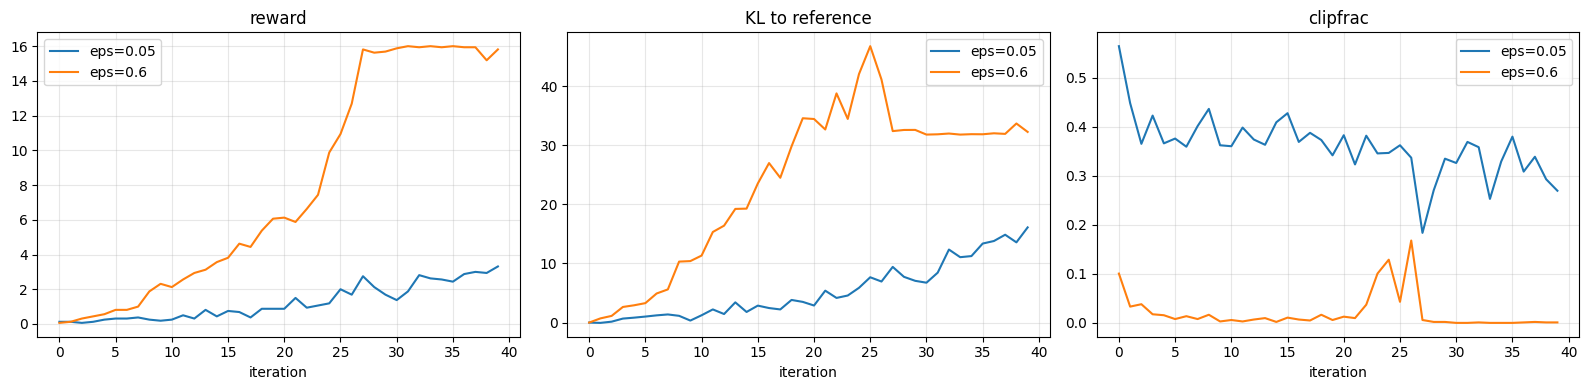

In [18]:
def run_clip_sweep(clip_values, iters=40):
    runs = {}
    for c_eps in clip_values:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, clip_eps=c_eps, iters=iters)
        print(f"\n--- clip_eps = {c_eps} ---")
        runs[c_eps] = train(c, log_every=5)  
    return runs

clip_sweep = run_clip_sweep([0.05, 0.6])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c_eps, H in clip_sweep.items():
    ax[0].plot(H["reward"], label=f"eps={c_eps}")
    ax[1].plot(H["kl"], label=f"eps={c_eps}")
    ax[2].plot(H["clipfrac"], label=f"eps={c_eps}")
ax[0].set_title("reward"); ax[1].set_title("KL to reference"); ax[2].set_title("clipfrac")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

Which gives faster but riskier learning?

ε=0.6 is faster (reward gain much quicker) but clearly riskier: it hits the same reward-hacking collapse we saw with weak β, just via a different mechanism (unrestricted step size instead of unrestricted reward-to-KL ratio). ε=0.05 is slow but far more conservative, it barely improving by iter 40, but with far more bounded KL and no evidence of collapse yet.

2. **GAE $\lambda$.** Compare $\lambda=0$ (high-bias, one-step TD) vs $\lambda=1$ (high-variance, Monte-Carlo). Watch the noise in the reward curve.


--- gae_lambda = 0.0 ---
it  0  reward  0.188  KL/seq   0.000  clipfrac 0.349  ent 3.518
it  5  reward  0.062  KL/seq   2.706  clipfrac 0.071  ent 2.944
it 10  reward  0.000  KL/seq   1.670  clipfrac 0.104  ent 3.998
it 15  reward  0.125  KL/seq   1.511  clipfrac 0.087  ent 3.991
it 20  reward  0.188  KL/seq   1.994  clipfrac 0.094  ent 3.762
it 25  reward  0.062  KL/seq   0.896  clipfrac 0.080  ent 3.253
it 30  reward  0.062  KL/seq   0.819  clipfrac 0.100  ent 3.465
it 35  reward  0.188  KL/seq   1.902  clipfrac 0.037  ent 3.582

--- gae_lambda = 1.0 ---
it  0  reward  0.188  KL/seq   0.000  clipfrac 0.386  ent 3.496
it  5  reward  0.312  KL/seq   1.123  clipfrac 0.155  ent 3.286
it 10  reward  1.875  KL/seq   8.493  clipfrac 0.051  ent 2.271
it 15  reward  3.125  KL/seq  15.830  clipfrac 0.042  ent 1.458
it 20  reward  4.312  KL/seq  23.142  clipfrac 0.064  ent 1.078
it 25  reward 13.625  KL/seq  30.482  clipfrac 0.011  ent 0.480
it 30  reward 14.000  KL/seq  32.077  clipfrac 0.008

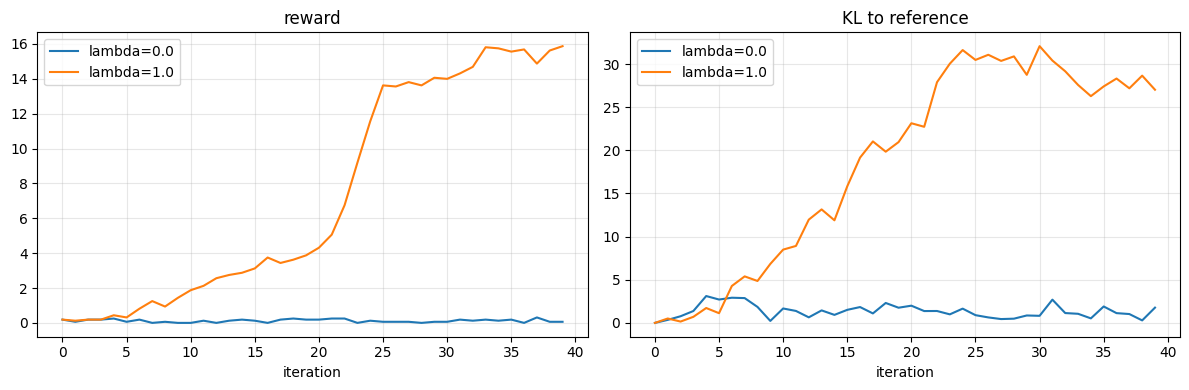

lambda=0.0: mean reward step-change std = 0.120
lambda=1.0: mean reward step-change std = 0.685


In [ ]:
import numpy as np

def run_lambda_sweep(lambdas, iters=40):
    runs = {}
    for lam in lambdas:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, gae_lambda=lam, iters=iters)
        print(f"\n--- gae_lambda = {lam} ---")
        runs[lam] = train(c, log_every=5)
    return runs

lambda_sweep = run_lambda_sweep([0.0, 1.0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lam, H in lambda_sweep.items():
    ax[0].plot(H["reward"], label=f"lambda={lam}")
    ax[1].plot(H["kl"], label=f"lambda={lam}")
ax[0].set_title("reward"); ax[1].set_title("KL to reference")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

for lam, H in lambda_sweep.items():
    r = np.array(H["reward"])
    diffs = np.diff(r)
    print(f"lambda={lam}: mean reward step-change std = {diffs.std():.3f}")

λ=0 → reward stayed flat, learning blocked. λ=1 → reward climbed to ~16, same as default. Reward only exists on the last token, so credit assignment to earlier tokens needs either the value function (λ=0) or direct return summation (λ=1). Since V starts untrained, λ=0 can't propagate signal back, lead to stalled learning. λ=1 bypasses this, so it works despite being theoretically "noisier."

3. **$\beta$ vs reward scale.** Switch `reward_fn` to the `!`-counting version (much larger magnitude). What happens to the good $\beta$ range? (Lesson: the KL coefficient is *scale-dependent* — same point as DPO's $\beta$.)


--- beta = 0.05 (exclaim reward) ---
it  0  reward  0.188  KL/seq   0.000  clipfrac 0.365  ent 3.624
it  5  reward  0.000  KL/seq   1.046  clipfrac 0.099  ent 3.178
it 10  reward  0.438  KL/seq   2.150  clipfrac 0.078  ent 3.072
it 15  reward  1.125  KL/seq   7.154  clipfrac 0.121  ent 2.590
it 20  reward  2.000  KL/seq  12.923  clipfrac 0.104  ent 2.470
it 25  reward  3.188  KL/seq  16.873  clipfrac 0.103  ent 2.444
it 30  reward  5.688  KL/seq  22.375  clipfrac 0.062  ent 2.277
it 35  reward 12.438  KL/seq  25.357  clipfrac 0.062  ent 1.689

--- beta = 0.2 (exclaim reward) ---
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.341  ent 3.310
it  5  reward  0.062  KL/seq   0.795  clipfrac 0.095  ent 3.558
it 10  reward  0.000  KL/seq   0.879  clipfrac 0.092  ent 3.488
it 15  reward  0.000  KL/seq   0.734  clipfrac 0.126  ent 3.777
it 20  reward  0.000  KL/seq   0.671  clipfrac 0.082  ent 3.513
it 25  reward  0.438  KL/seq   1.791  clipfrac 0.057  ent 3.350
it 30  reward  0.250  KL/seq 

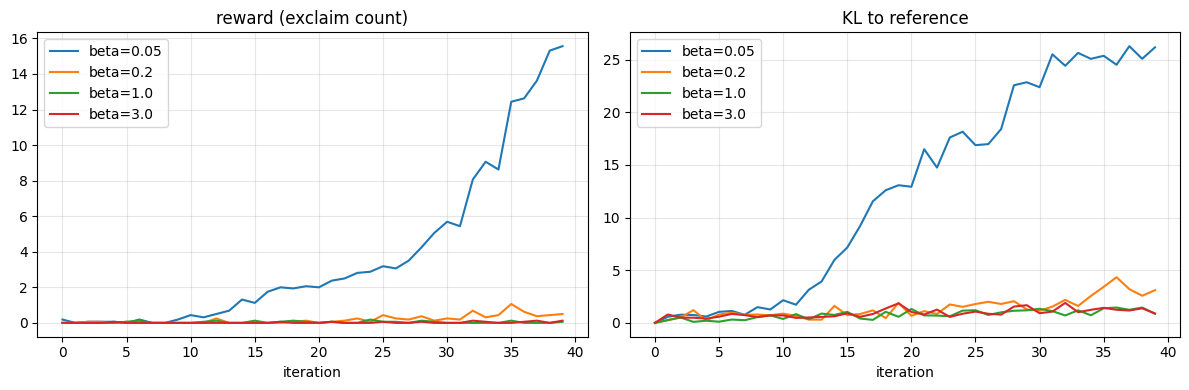

In [20]:
def reward_fn_exclaim(texts):
    out = []
    for t in texts:
        out.append(float(t.count("!")))
    return torch.tensor(out, device=device)

orig_reward_fn = reward_fn
reward_fn = reward_fn_exclaim

def run_beta_scale_sweep(betas, iters=40):
    runs = {}
    for b in betas:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, kl_coef=b, iters=iters)
        print(f"\n--- beta = {b} (exclaim reward) ---")
        runs[b] = train(c, log_every=5)
    return runs

beta_scale_sweep = run_beta_scale_sweep([0.05, 0.2, 1.0, 3.0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b, H in beta_scale_sweep.items():
    ax[0].plot(H["reward"], label=f"beta={b}")
    ax[1].plot(H["kl"], label=f"beta={b}")
ax[0].set_title("reward (exclaim count)"); ax[1].set_title("KL to reference")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

reward_fn = orig_reward_fn

What happens to the good $\beta$ range?

Compared to before, β=0.2 used to be the "sweet spot" (moderate reward gain, coherent text) with the word-counting reward. With the !-counting reward, β=0.2 now behaves like β=1.0 did before where it's too strong, learning is fully suppressed. The "good β" range shifted upward, but not all the way to 3.0 — even 0.2 is now overkill.

4. **PPO epochs.** Push `ppo_epochs` to 8. 

In [22]:
def ppo_update_verbose(seq, L, T, old_lp, old_V, adv, ret, cfg, opt):
    adv_n = (adv - adv.mean())/(adv.std()+1e-8) if cfg.normalize_adv else adv
    epoch_clipfracs = []
    for ep in range(cfg.ppo_epochs):
        new_lp, new_V, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        pg = -torch.min(ratio*adv_n,
                        torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps)*adv_n).mean()
        vf = 0.5 * (new_V - ret).pow(2).mean()
        loss = pg + cfg.vf_coef*vf - cfg.ent_coef*ent.mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        cf = ((ratio-1).abs() > cfg.clip_eps).float().mean().item()
        epoch_clipfracs.append(cf)
    return epoch_clipfracs

policy.load_state_dict(copy.deepcopy(policy_fresh_state))
opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
c8 = replace(cfg, ppo_epochs=8)

seq, L, T, texts = rollout(c8)
with torch.no_grad():
    old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
    ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
kl_tok = old_lp - ref_lp
R = reward_fn(texts)
rew = build_rewards(R, kl_tok, c8.kl_coef)
adv, ret = compute_gae(rew, old_V, c8.gamma, c8.gae_lambda)

epoch_cf = ppo_update_verbose(seq, L, T, old_lp, old_V, adv, ret, c8, opt)
print("clipfrac per epoch (single rollout, 8 reuse passes):")
for i, cf in enumerate(epoch_cf):
    print(f"  epoch {i}: clipfrac = {cf:.3f}")

clipfrac per epoch (single rollout, 8 reuse passes):
  epoch 0: clipfrac = 0.000
  epoch 1: clipfrac = 0.211
  epoch 2: clipfrac = 0.438
  epoch 3: clipfrac = 0.617
  epoch 4: clipfrac = 0.734
  epoch 5: clipfrac = 0.805
  epoch 6: clipfrac = 0.852
  epoch 7: clipfrac = 0.863


Why does `clipfrac` rise? When does data reuse start to hurt?

Clipfrac rises because each gradient step moves the policy further from `π_old` (which generated the batch), so the ratio drifts further outside the trust region with every reused epoch. Data reuse starts to hurt once clipfrac gets high, (~40-50%+, around epoch 2-3 here) since most gradient signal is being clipped away (wasted compute) and the importance-sampling approximation becomes unreliable since the policy has diverged too far from the one that sampled the data.

5. **Kill the critic.** Replace advantages with `returns - returns.mean()` (no value head). 

it  0  reward  0.125  KL/seq   0.000  clipfrac 0.344  ent 3.642
it  5  reward  0.562  KL/seq   1.889  clipfrac 0.151  ent 3.113
it 10  reward  1.062  KL/seq   3.649  clipfrac 0.077  ent 2.585
it 15  reward  3.188  KL/seq  14.022  clipfrac 0.033  ent 1.418
it 20  reward  3.688  KL/seq  17.458  clipfrac 0.032  ent 0.676
it 25  reward  3.750  KL/seq  17.477  clipfrac 0.033  ent 0.579
it 30  reward  4.875  KL/seq  23.612  clipfrac 0.106  ent 0.584
it 35  reward 12.250  KL/seq  28.431  clipfrac 0.098  ent 0.460
it  0  reward  0.125  KL/seq   0.000  clipfrac 0.311
it  5  reward  0.375  KL/seq   2.425  clipfrac 0.127
it 10  reward  1.438  KL/seq   6.833  clipfrac 0.101
it 15  reward  2.562  KL/seq  12.248  clipfrac 0.132
it 20  reward  4.312  KL/seq  24.371  clipfrac 0.125
it 25  reward  6.750  KL/seq  33.671  clipfrac 0.153
it 30  reward  7.375  KL/seq  28.544  clipfrac 0.062
it 35  reward  7.938  KL/seq  27.155  clipfrac 0.040


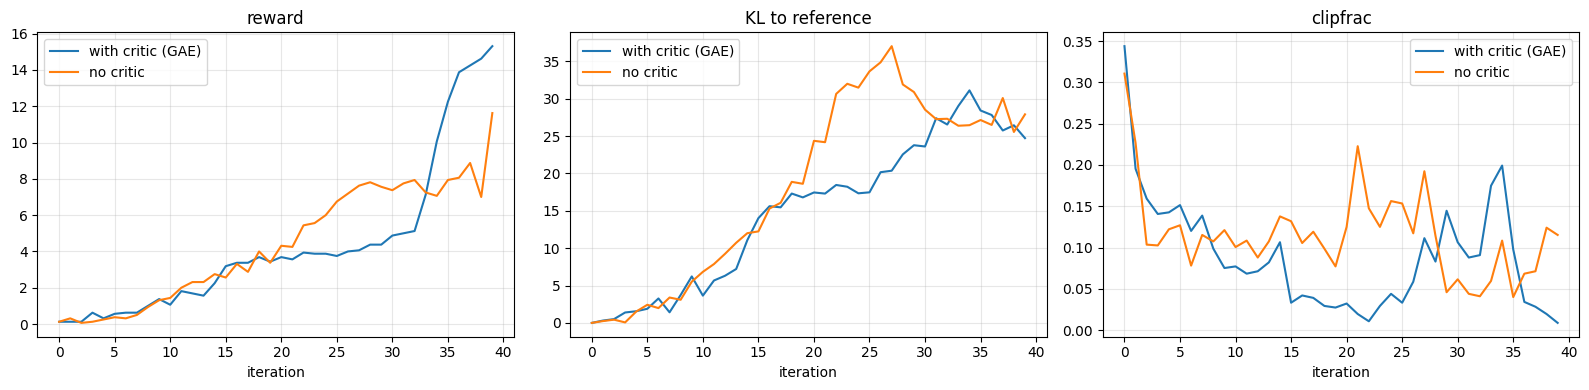

In [25]:
def compute_no_critic_adv(rewards, gamma):
    B, T = rewards.shape
    returns = torch.zeros_like(rewards)
    running = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        running = rewards[:, t] + gamma * running
        returns[:, t] = running
    adv = returns - returns.mean()
    return adv, returns

def ppo_update_no_critic(seq, L, T, old_lp, adv, cfg, opt):
    adv_n = (adv - adv.mean()) / (adv.std() + 1e-8) if cfg.normalize_adv else adv
    stats = {"clipfrac": [], "pg": [], "ent": []}
    for _ in range(cfg.ppo_epochs):
        new_lp, _, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        pg = -torch.min(
            ratio * adv_n,
            torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps) * adv_n
        ).mean()
        loss = pg - cfg.ent_coef * ent.mean()
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()
        stats["clipfrac"].append(((ratio - 1).abs() > cfg.clip_eps).float().mean().item())
        stats["pg"].append(pg.item())
        stats["ent"].append(ent.mean().item())
    return {k: sum(v) / len(v) for k, v in stats.items()}

def train_no_critic(cfg, log_every=5):
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    H = {"reward": [], "kl": [], "clipfrac": [], "entropy": []}
    for it in range(cfg.iters):
        seq, L, T, texts = rollout(cfg)
        with torch.no_grad():
            old_lp, _, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
            ref_lp, _, _ = aligned_logps_values(ref, seq, L, T, is_policy=False)
        kl_tok = old_lp - ref_lp
        R = reward_fn(texts)
        rew = build_rewards(R, kl_tok, cfg.kl_coef)
        adv, ret = compute_no_critic_adv(rew, cfg.gamma)
        s = ppo_update_no_critic(seq, L, T, old_lp, adv, cfg, opt)
        H["reward"].append(R.mean().item())
        H["kl"].append(kl_tok.sum(-1).mean().item())
        H["clipfrac"].append(s["clipfrac"])
        H["entropy"].append(s["ent"])
        if it % log_every == 0:
            print(f"it{it:3d}  reward {R.mean():6.3f}  KL/seq {kl_tok.sum(-1).mean():7.3f}  clipfrac {s['clipfrac']:.3f}")
    return H

cfg_cmp = replace(cfg, iters=40)

policy.load_state_dict(copy.deepcopy(policy_fresh_state))
H_with_critic = train(cfg_cmp, log_every=5)

policy.load_state_dict(copy.deepcopy(policy_fresh_state))
H_no_critic = train_no_critic(cfg_cmp, log_every=5)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(H_with_critic["reward"], label="with critic (GAE)")
ax[0].plot(H_no_critic["reward"], label="no critic")
ax[1].plot(H_with_critic["kl"], label="with critic (GAE)")
ax[1].plot(H_no_critic["kl"], label="no critic")
ax[2].plot(H_with_critic["clipfrac"], label="with critic (GAE)")
ax[2].plot(H_no_critic["clipfrac"], label="no critic")

ax[0].set_title("reward")
ax[1].set_title("KL to reference")
ax[2].set_title("clipfrac")
for a in ax:
    a.set_xlabel("iteration")
    a.legend()
    a.grid(alpha=.3)

plt.tight_layout()
plt.show()

What did GAE buy you?

GAE bought me lower-variance, better-directed policy updates. The critic+GAE run reached higher final reward and kept KL growth better controlled than the no-critic run, which learned but was noisier and less sample-efficient.